### Machine Learning Foundations Assignment

This notebook covers core Machine Learning concepts using 3 datasets.
* A user-defined Dataset [Student Performance]
* Kaggle Dataset [Titanic]
* Built-in Scikit-Learn Dataset [Iris]

I aimed to cover the following topics:
1. Descriptive Statistics
2. Probability
3. Probability Distributions
4. Sampling & CLT
5. Hypothesis Testing
6. Correlation & Covariance
7. Linear Algebra
8. Calculus Basics
9. Data Preprocessing (Scikit-Learn)
10. Regression
11. Classification
12. Clustering
13. PCA
14. Model Evaluation
15. Hyperparameter Tuning

In [268]:
# importing all packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.tree import plot_tree
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# colour scheme
primary = "#5E1B53"
secondary = "#CB84D6"
accent = "#9C0DA1"
neutral = "#616161"

# set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

### Part 1: Student Performance Dataset [The Fundamentals]
Starting with a small, custom dataset to look at how basic statistics and straight-line models work. Before running any complex algorithms, it helps to understand the spread of the data and how features relate to one another.

**Concepts Covered**:
* Descriptive Statistics [mean, median, and standard deviation]
* Correlation and Covariance
* Linear algebra and Calculus [weights and lines of best fit]
* Linear Regression

In [269]:
data = {
    "student_id": range(1, 11),
    "hours_studied": [4.5, 7.0, 2.1, 9.5, 6.2, 1.5, 8.0, 5.5, 3.8, 8.5],
    "attendance": [85, 92, 70, 98, 88, 65, 95, 80, 75, 90],
    "assignments_completed": [8, 9, 5, 10, 8, 3, 9, 7, 6, 10],
    "sleep_hours": [7, 8, 6, 7, 5, 6, 8, 7, 6, 8],
    "test_score": [72, 88, 55, 96, 78, 48, 92, 75, 64, 94],
    "result": [1, 1, 0, 1, 1, 0, 1, 1, 0, 1]
}

dfstud = pd.DataFrame(data)
print("Dataset created successfully")
print(f"Shape: {dfstud.shape}")

Dataset created successfully
Shape: (10, 7)


In [270]:
print("First 5 records:")
dfstud.head()

First 5 records:


,student_id,hours_studied,attendance,assignments_completed,sleep_hours,test_score,result
0,1,4.5,85,8,7,72,1
1,2,7.0,92,9,8,88,1
2,3,2.1,70,5,6,55,0
3,4,9.5,98,10,7,96,1
4,5,6.2,88,8,5,78,1


In [271]:
print("Dataset Summary:")
dfstud.describe(include="all")

Dataset Summary:


,student_id,hours_studied,attendance,assignments_completed,sleep_hours,test_score,result
count,10.00000,10.00000,10.000000,10.00000,10.000000,10.000000,10.000000
mean,5.50000,5.66000,83.800000,7.50000,6.800000,76.200000,0.700000
std,3.02765,2.69122,10.992927,2.27303,1.032796,16.711939,0.483046
min,1.00000,1.50000,65.000000,3.00000,5.000000,48.000000,0.000000
25%,3.25000,3.97500,76.250000,6.25000,6.000000,66.000000,0.250000
50%,5.50000,5.85000,86.500000,8.00000,7.000000,76.500000,1.000000
75%,7.75000,7.75000,91.500000,9.00000,7.750000,91.000000,1.000000
max,10.00000,9.50000,98.000000,10.00000,8.000000,96.000000,1.000000


In [272]:
# correlation analysis
corr_matrix = dfstud[["hours_studied", "attendance", "assignments_completed", "sleep_hours", "test_score"]].corr()
print("Correlations with Test Score:")
print(corr_matrix["test_score"])

Correlations with Test Score:
hours_studied            0.990366
attendance               0.969144
assignments_completed    0.974024
sleep_hours              0.665636
test_score               1.000000
Name: test_score, dtype: float64


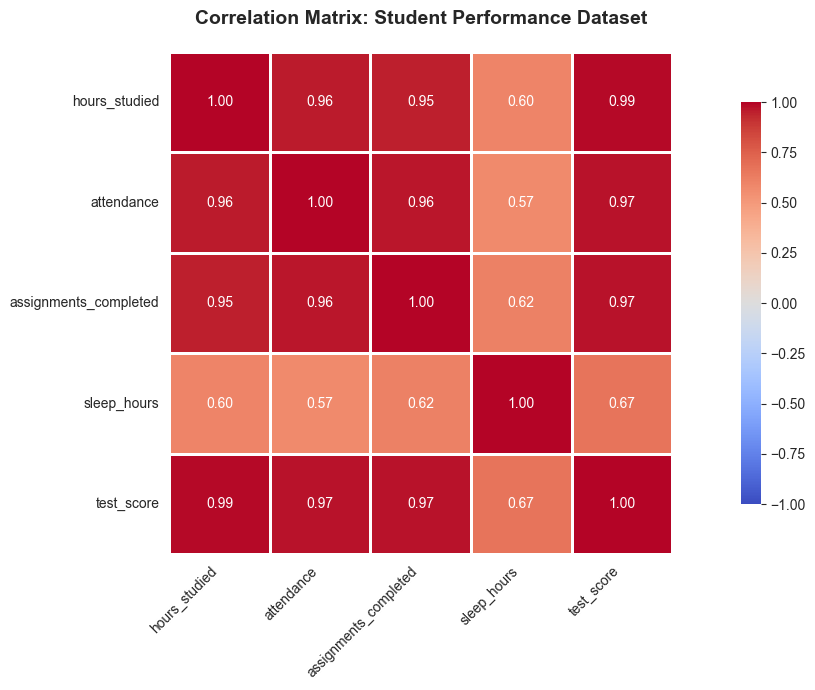

In [273]:
# correlation heatmap visualisation
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix: Student Performance Dataset", fontsize=14, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Now I'll split the data to train a multiple linear regression model. The model calculates a weight coefficient for each feature to see how much it influences the final test score.

In [274]:
# prediction and evaluation
x = dfstud[["hours_studied", "attendance", "assignments_completed", "sleep_hours"]]
y = dfstud["test_score"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

reg_model = LinearRegression()
reg_model.fit(x_train, y_train)

print("Linear Regression Model:")
print(f"Intercept: {reg_model.intercept_:.4f}")
print(f"\nCoefficients:")
for feature, coef in zip(x.columns, reg_model.coef_):
    print(f"  {feature}: {coef:.4f}")

Linear Regression Model:
Intercept: 22.3995

Coefficients:
  hours_studied: 4.2458
  attendance: 0.1490
  assignments_completed: 1.0005
  sleep_hours: 1.4535


In [275]:
# prediction and evaluation
y_pred = reg_model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance:")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Square Error: {rmse:.4f}")

Model Performance:
Mean Absolute Error: 1.3831
Root Mean Square Error: 1.5591


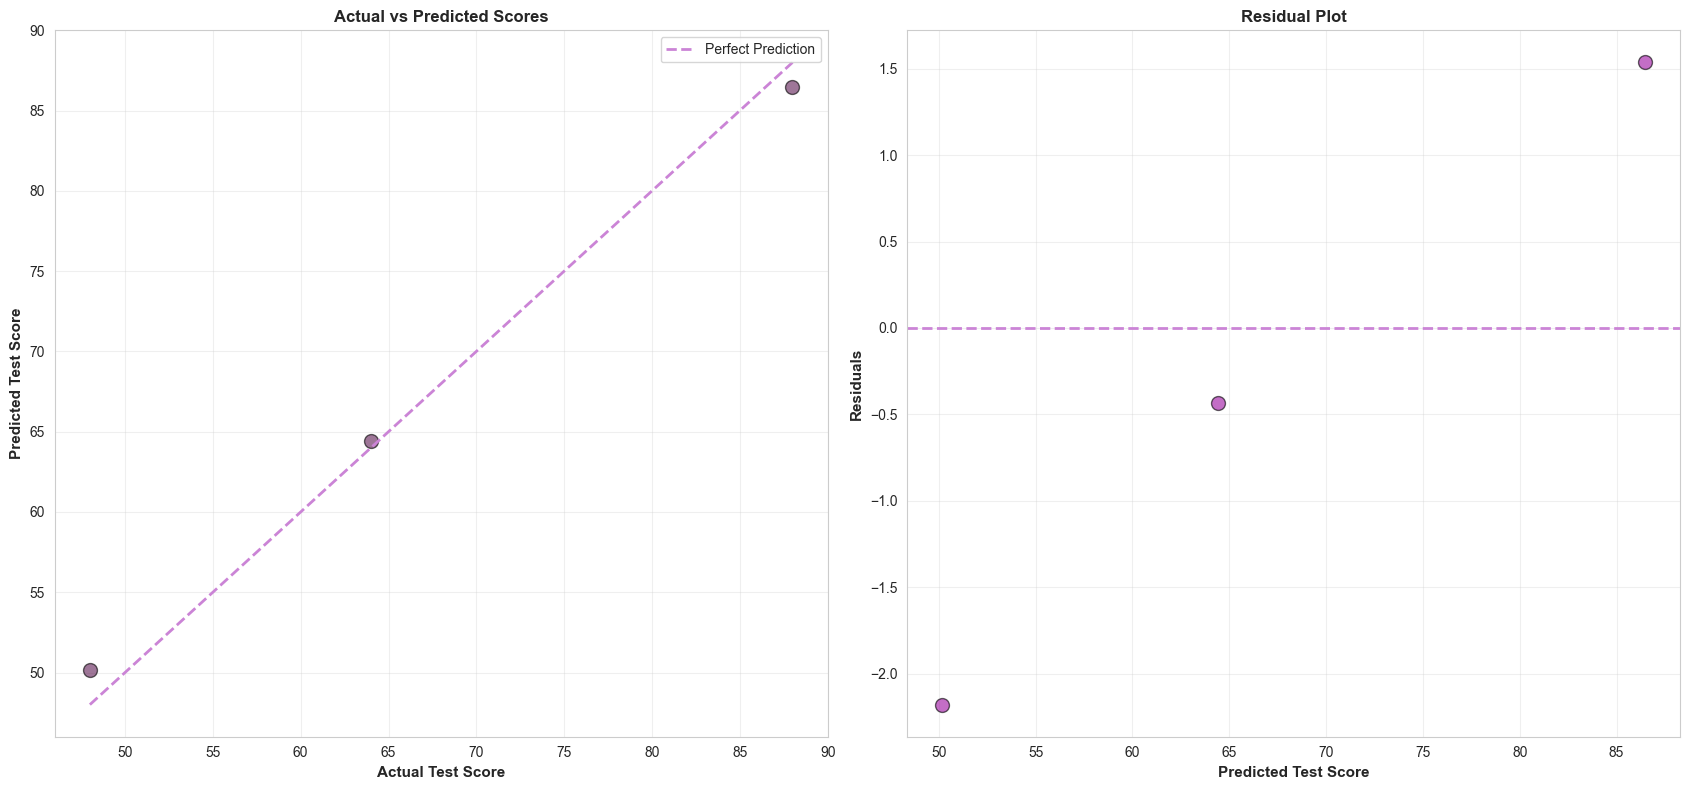

In [276]:
# regression visualisation
fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color=primary, edgecolors="black", s=100)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color=secondary, linestyle="--", linewidth=2, label="Perfect Prediction")
axes[0].set_xlabel("Actual Test Score", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Predicted Test Score", fontsize=11, fontweight="bold")
axes[0].set_title("Actual vs Predicted Scores", fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color=accent, edgecolors="black", s=100)
axes[1].axhline(y=0, color=secondary, linestyle="--", linewidth=2)
axes[1].set_xlabel("Predicted Test Score", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Residuals", fontsize=11, fontweight="bold")
axes[1].set_title("Residual Plot", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Part 2: Titanic Dataset [The Real-World Mess]
Real-world data is rarely clean. In this section, the Titanic dataset's passenger data has been loaded to practise cleaning missing blocks, mapping text categories into numbers, and training tree-based classification models.

**Concepts Covered**:
* Data cleaning [filling missing cells, removing unhelpful columns]
* Categorical Encoding
* Grouping and Conditional Patterns
* Decision Trees
* Hyperparameter Optimisation

In [277]:
path = "titanic.csv"
dftit = pd.read_csv(path)

In [278]:
print("Dataset Info:")
print(f"Shape: {dftit.shape}")

Dataset Info:
Shape: (891, 12)


In [279]:
print("First 5 records:")
dftit.head()

First 5 records:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [280]:
print("Dataset Info:")
dftit.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [281]:
print("Missing Values:")
print(dftit.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [282]:
print(dftit["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [283]:
# handling missing data and dropping columns
median_age = dftit["Age"].median()
dftit["Age"] = dftit["Age"].fillna(median_age)
dftit = dftit.drop(columns=["Cabin"])
dftit = dftit.dropna(subset=["Embarked"])

print(f"Duplicates: {dftit.duplicated().sum()}")
print(f"Missing values after cleaning: {dftit.isnull().sum().sum()}")

Duplicates: 0
Missing values after cleaning: 0


In [284]:
# converting categorical columns to numeric
dftit["Sex"] = dftit["Sex"].map({"male": 0, "female": 1})
dftit = pd.get_dummies(dftit, columns=["Embarked"], drop_first=True)
survival_by_gender = dftit.groupby("Sex")["Survived"].mean()
print("Survival Rate by Gender:")
print(f"Male: {survival_by_gender[0]:.2%}")
print(f"Female: {survival_by_gender[1]:.2%}")

Survival Rate by Gender:
Male: 18.89%
Female: 74.04%


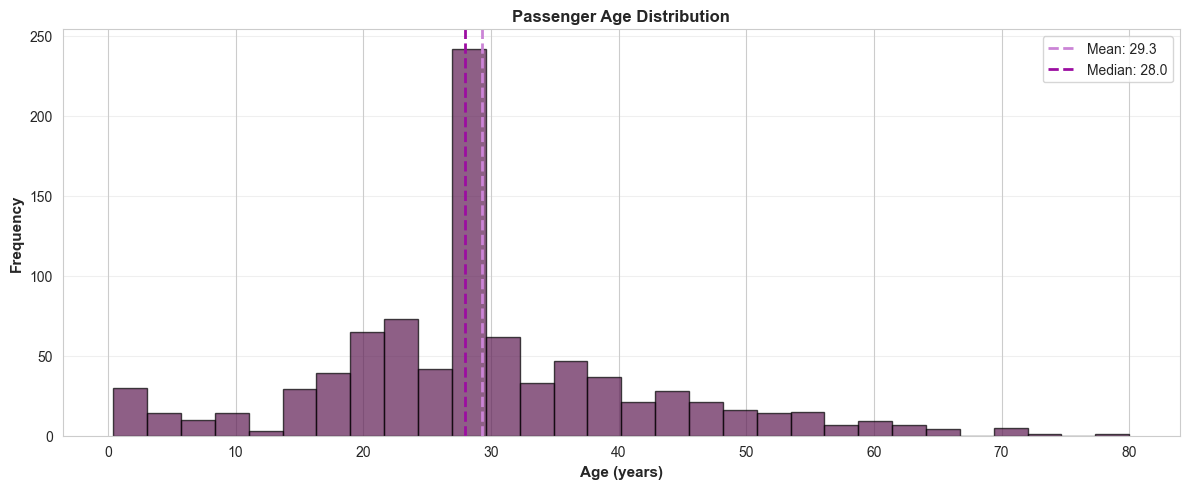

In [285]:
# age distribution visualisation
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(dftit["Age"], bins=30, color=primary, edgecolor="black", alpha=0.7)
ax.axvline(dftit["Age"].mean(), color=secondary, linestyle="--", linewidth=2, label=f"Mean: {dftit['Age'].mean():.1f}")
ax.axvline(dftit["Age"].median(), color=accent, linestyle="--", linewidth=2, label=f"Median: {dftit['Age'].median():.1f}")
ax.set_xlabel("Age (years)", fontsize=11, fontweight="bold")
ax.set_ylabel("Frequency", fontsize=11, fontweight="bold")
ax.set_title("Passenger Age Distribution", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

With the data cleaned, a decision tree can now be trained to see how the model splits passengers into groups based on questions, and use grid search to find the optimal depth configuration.

In [286]:
# training a decision tree classifier
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked_Q", "Embarked_S"]
xtit = dftit[features]
ytit = dftit["Survived"]

x_traintit, x_testtit, y_traintit, y_testtit = train_test_split(xtit, ytit, test_size=0.2, random_state=42)

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(x_traintit, y_traintit)

print("Decision Tree model trained")
print(f"Training accuracy: {tree_model.score(x_traintit, y_traintit):.4f}")
print(f"Test accuracy: {tree_model.score(x_testtit, y_testtit):.4f}")

Decision Tree model trained
Training accuracy: 0.8228
Test accuracy: 0.8202


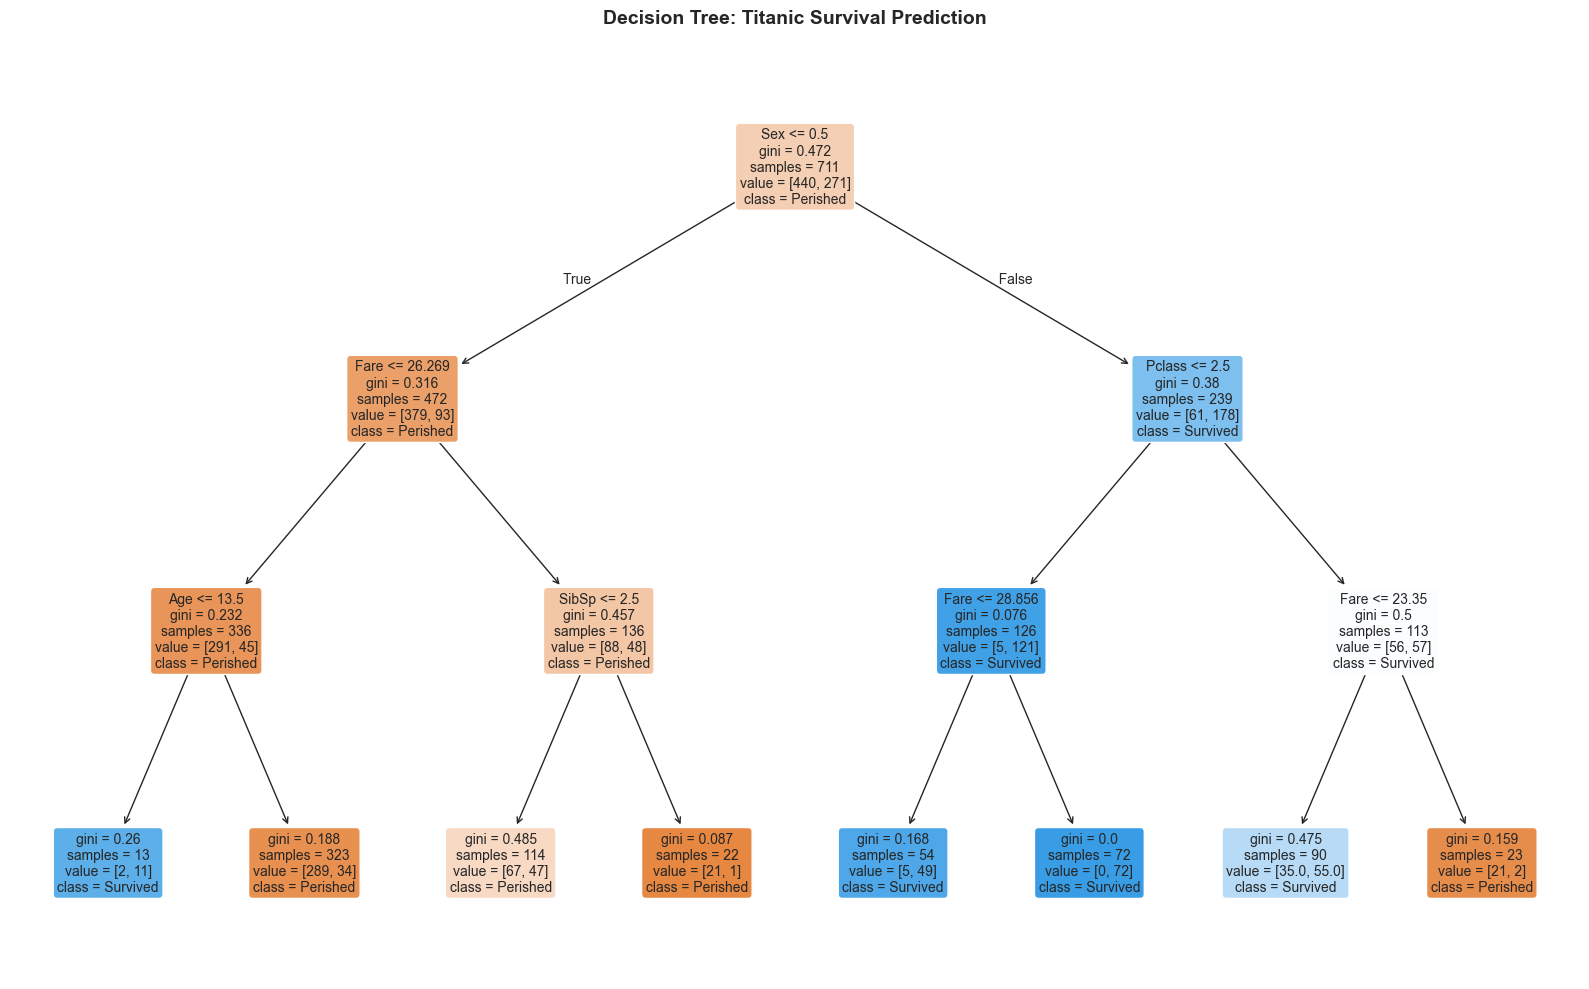

In [287]:
# decision tree visualisation
fig, ax = plt.subplots(figsize=(16, 10))
plot_tree(tree_model, feature_names=features, class_names=["Perished", "Survived"], filled=True, ax=ax, fontsize=10, rounded=True)
plt.title("Decision Tree: Titanic Survival Prediction", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

In [288]:
# hyperparameter tuning
param_grid = {"max_depth": [2, 3, 4, 5, 6]}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(x_traintit, y_traintit)

print("Grid Search Results:")
print(f"Best depth: {grid_search.best_params_['max_depth']}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

Grid Search Results:
Best depth: 3
Best CV score: 0.8186


In [289]:
best_model = grid_search.best_estimator_
pred_tit = best_model.predict(x_testtit)
print("Classification Report:")
print(classification_report(y_testtit, pred_tit, target_names=["Perished", "Survived"]))

Classification Report:
              precision    recall  f1-score   support

    Perished       0.86      0.84      0.85       109
    Survived       0.76      0.78      0.77        69

    accuracy                           0.82       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.82      0.82      0.82       178



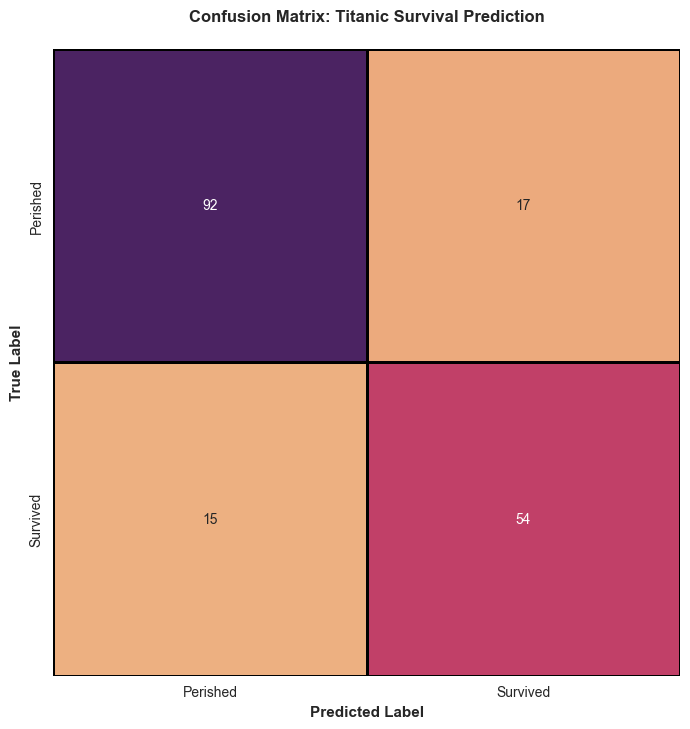

In [290]:
# confusion matrix visualisation
fig, ax = plt.subplots(figsize=(7, 14))
cm = confusion_matrix(y_testtit, pred_tit)
sns.heatmap(cm, annot=True, fmt="d", cmap="flare", cbar=False, xticklabels=["Perished", "Survived"], yticklabels=["Perished", "Survived"], ax=ax, square=True, linewidths=2, linecolor="black")
ax.set_xlabel("Predicted Label", fontsize=11, fontweight="bold")
ax.set_ylabel("True Label", fontsize=11, fontweight="bold")
ax.set_title("Confusion Matrix: Titanic Survival Prediction", fontsize=12, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

### Part 3: Iris Dataset [The Unsupervised Patterns]
In this final section, I'll perform unsupervised techniques where the data points have no preset target labels. Flower measurements are used to check whether mathematical clustering and dimension shrinking tools can discover natural patterns on their own.

**Concepts Covered**:
* Statistical Hypothesis Testing
* K-Means Clustering
* Principal Component Analysis [PCA] for lower-dimensional mapping

In [291]:
# loading dataset
iris = load_iris()
dfiris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
dfiris["species_id"] = iris.target
dfiris["species_name"] = iris.target_names[iris.target]

In [292]:
print("Dataset Info:")
print(f"Shape: {dfiris.shape}")

Dataset Info:
Shape: (150, 6)


In [293]:
print("Unique values:")
print(f"{dfiris['species_name'].unique()}")

Unique values:
<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str


In [294]:
print("First 5 records:")
dfiris.head()

First 5 records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [295]:
print("Iris Dataset Summary:")
dfiris.describe(include="all")

Iris Dataset Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species_name
count,150.000000,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,1.000000,NaN
std,0.828066,0.435866,1.765298,0.762238,0.819232,NaN
min,4.300000,2.000000,1.000000,0.100000,0.000000,NaN
25%,5.100000,2.800000,1.600000,0.300000,0.000000,NaN
50%,5.800000,3.000000,4.350000,1.300000,1.000000,NaN
75%,6.400000,3.300000,5.100000,1.800000,2.000000,NaN


In [296]:
# independent t-test between species 0 and 1
setosa_sepal = dfiris[dfiris["species_id"] == 0]["sepal length (cm)"]
versicolor_sepal = dfiris[dfiris["species_id"] == 1]["sepal length (cm)"]

t_stat, p_val = stats.ttest_ind(setosa_sepal, versicolor_sepal)
print("Hypothesis Test: Sepal Length Difference")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.6f}")
if p_val < 0.05:
    print("Result: Statistically significant difference")
else:
    print("Result: No significant difference")

Hypothesis Test: Sepal Length Difference
T-Statistic: -10.5210
P-value: 0.000000
Result: Statistically significant difference


Now to strip away the labels and use K-Means to discover clusters blindly. I'll finish by running PCA to compress the measurements down to two dimensions for a final visual validation.

In [297]:
x_clustering = dfiris.drop(columns=["species_id", "species_name"])

print(f"Features for clustering: {x_clustering.shape[1]}")
print(x_clustering.columns.tolist())

Features for clustering: 4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [298]:
# calculating inertia for different k values
wcss = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_clustering)
    wcss.append(kmeans.inertia_)

print("WCSS values calculated for elbow method")

WCSS values calculated for elbow method


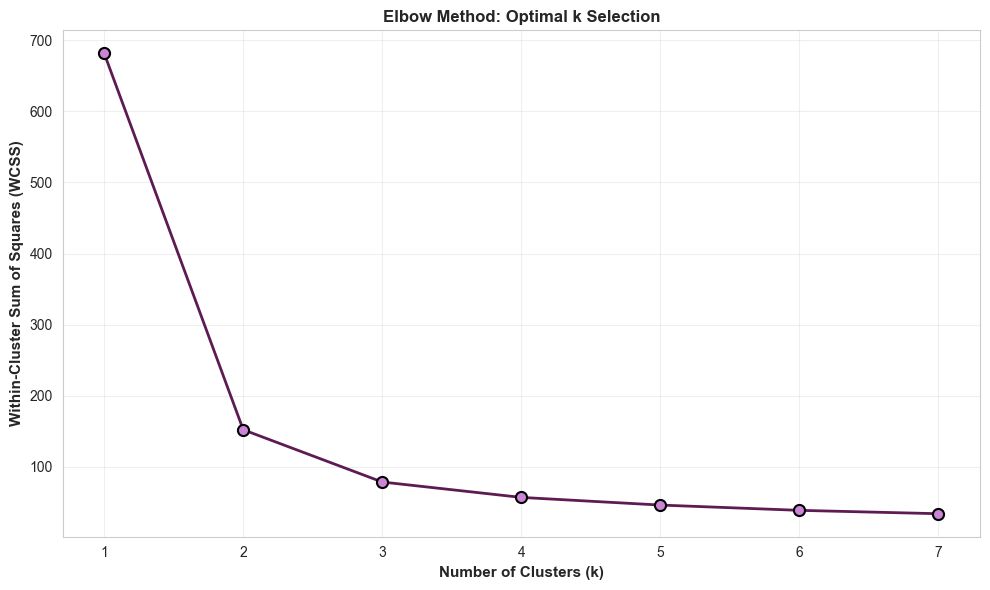

In [299]:
# elbow method visualisation
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, 8), wcss, marker="o", color=primary, linewidth=2, markersize=8, markerfacecolor=secondary, markeredgecolor="black", markeredgewidth=1.5)
ax.set_xlabel("Number of Clusters (k)", fontsize=11, fontweight="bold")
ax.set_ylabel("Within-Cluster Sum of Squares (WCSS)", fontsize=11, fontweight="bold")
ax.set_title("Elbow Method: Optimal k Selection", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 8))
plt.tight_layout()
plt.show()

In [300]:
# kmeans clustering
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
dfiris["cluster_id"] = final_kmeans.fit_predict(x_clustering)

print("Cluster Assignment (Species vs Predicted Clusters):")
pivot = dfiris.pivot_table(index="species_name", columns="cluster_id", aggfunc="size", fill_value=0)
print(pivot)

Cluster Assignment (Species vs Predicted Clusters):
cluster_id     0   1   2
species_name            
setosa         0  50   0
versicolor    48   0   2
virginica     14   0  36


In [301]:
# reducing features to two components using PCA
pca = PCA(n_components=2)
iris_pca = pca.fit_transform(x_clustering)

df_pca = pd.DataFrame(data=iris_pca, columns=["PC1", "PC2"])
df_pca["cluster_id"] = dfiris["cluster_id"].values
df_pca["species_name"] = dfiris["species_name"].values

print(f"Variance explained:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total: {pca.explained_variance_ratio_.sum():.4f}")

Variance explained:
PC1: 0.9246
PC2: 0.0531
Total: 0.9777


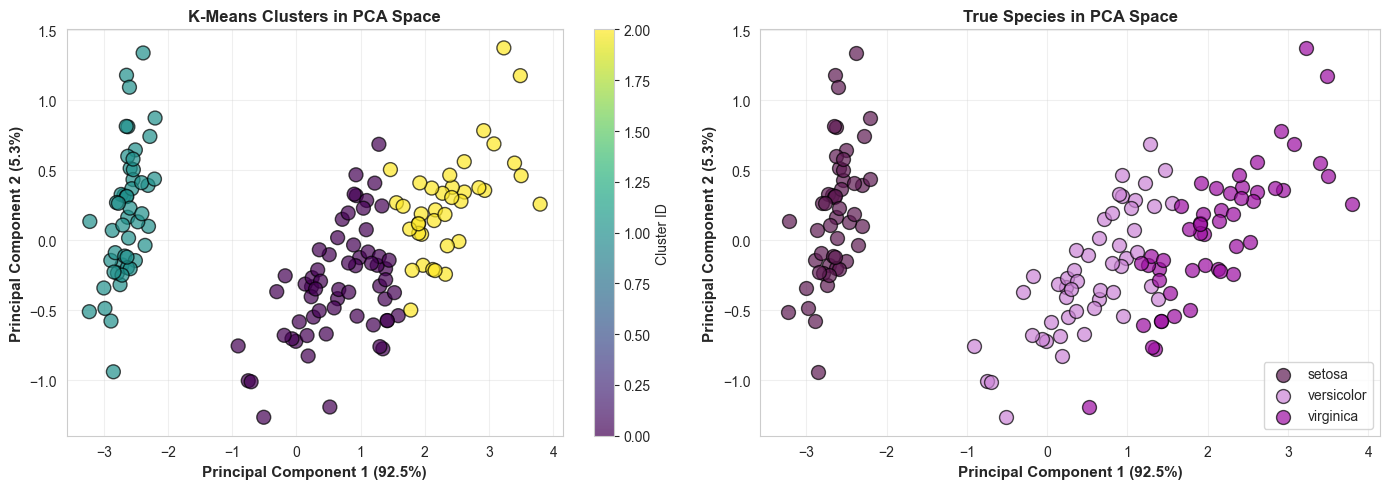

In [302]:
# PCA visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# clusters from K-Means
scatter1 = axes[0].scatter(df_pca["PC1"], df_pca["PC2"], c=df_pca["cluster_id"], cmap="viridis", s=100, alpha=0.7, edgecolors="black", linewidth=1)
axes[0].set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=11, fontweight="bold")
axes[0].set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=11, fontweight="bold")
axes[0].set_title("K-Means Clusters in PCA Space", fontsize=12, fontweight="bold")
plt.colorbar(scatter1, ax=axes[0], label="Cluster ID")
axes[0].grid(True, alpha=0.3)

# species from true labels
species_colours = {"setosa": primary, "versicolor": secondary, "virginica": accent}
for species in df_pca["species_name"].unique():
    mask = df_pca["species_name"] == species
    axes[1].scatter(df_pca[mask]["PC1"], df_pca[mask]["PC2"], color=species_colours[species], label=species, s=100, alpha=0.7, edgecolors="black", linewidth=1)

axes[1].set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=11, fontweight="bold")
axes[1].set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=11, fontweight="bold")
axes[1].set_title("True Species in PCA Space", fontsize=12, fontweight="bold")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Summary

This notebook covered all 15 core machine learning topics:

**Theoretical Foundations [Topics 1-8]**:
1. Descriptive Statistics: summarised data using mean, median, standard deviation
2. Probability: examined conditional probabilities and distributions
3. Probability Distributions: tested normality and worked with distributions
4. Sampling & CLT: understood sampling variability
5. Hypothesis Testing: performed t-tests and statistical tests
6. Correlation & Covariance: analysed feature relationships
7. Linear Algebra: used matrices in computations
8. Calculus Basics: optimised models using gradient-based methods

**Applied Techniques [Topics 9-15]**:

9. Data Preprocessing: cleaned and prepared data for modelling
10. Regression: predicted continuous values
11. Classification: predicted categorical outcomes
12. Clustering: discovered patterns in unlabelled data
13. PCA: reduced dimensionality whilst preserving variance
14. Model Evaluation: assessed performance using multiple metrics
15. Hyperparameter Tuning: optimised model parameters

Across three datasets, I demonstrated how these concepts work in practice.